In [1]:
import sys
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/dlimp')
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/')
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/octo')

from octo.data.oxe import make_oxe_dataset_kwargs
from octo.data.dataset import make_single_dataset

import mediapy
import matplotlib.pyplot as plt



2025-04-26 23:17:16.077585: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-26 23:17:16.081203: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-26 23:17:16.092886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745709436.113263 1416091 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745709436.119406 1416091 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745709436.134023 1416091 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [16]:
dataset_kwargs = make_oxe_dataset_kwargs(
    "aria_dataset",
    "/nfs/nfs2/users/riadoshi/bigvision_palivla/ignore",
)
# dataset_kwargs['use_cot'] = True
# dataset_kwargs['cot_data_path'] = 'gs://multi-robot-bucket2/data/generated_data'
dataset = make_single_dataset(dataset_kwargs, train=True) # load the train split
iterator = dataset.iterator()

In [17]:
count = 0
for _ in iterator:
    count += 1
count


2025-04-26 23:37:13.612033: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


27

In [3]:
traj = next(iterator)
traj.keys()

dict_keys(['observation', 'task', 'action', 'dataset_name', 'traj_idx', 'frame_idx', 'action_chunk_size', 'use_actions', 'hand_left', 'hand_right', 'has_hand_left', 'has_hand_right', 'gaze_3d', 'action_pad_mask', 'action_head_masks'])

In [20]:
traj['action'].shape

(71, 1, 1, 6)

In [18]:
traj['hand_left']

array([[132., 341.,   0.],
       [132., 344.,   0.],
       [130., 347.,   0.],
       [126., 351.,   0.],
       [122., 355.,   0.],
       [119., 359.,   0.],
       [118., 359.,   0.],
       [116., 364.,   0.],
       [116., 367.,   0.],
       [116., 370.,   0.],
       [117., 374.,   0.],
       [117., 376.,   0.],
       [117., 375.,   0.],
       [116., 373.,   0.],
       [116., 369.,   0.],
       [115., 366.,   0.],
       [115., 362.,   0.],
       [114., 360.,   0.],
       [113., 359.,   0.],
       [112., 360.,   0.],
       [112., 361.,   0.],
       [112., 361.,   0.],
       [111., 360.,   0.],
       [112., 359.,   0.],
       [111., 356.,   0.],
       [112., 354.,   0.],
       [112., 354.,   0.],
       [114., 359.,   0.],
       [117., 367.,   0.],
       [122., 369.,   0.],
       [127., 368.,   0.],
       [129., 356.,   0.],
       [127., 330.,   0.],
       [123., 288.,   0.],
       [118., 244.,   0.],
       [113., 212.,   0.],
       [111., 185.,   0.],
 

In [8]:
mediapy.show_video(traj['observation']['image_primary'].squeeze(), fps=1)

This browser does not support the video tag.


In [19]:
# Fix the bug in the get_hand_centroids function
# The right_centroids were incorrectly appending right_centroids instead of right_centroid
def get_hand_centroids(
    has_left_hand, 
    has_right_hand,
    left_hand,
    right_hand
):
    left_centroids, right_centroids = [], []

    # left centroids
    for i, left_centroid in enumerate(left_hand):
        if has_left_hand[i]:
            left_centroids.append(left_centroid)
        else:
            left_centroids.append(None)

    # right centroids
    for i, right_centroid in enumerate(right_hand):
        if has_right_hand[i]:
            right_centroids.append(right_centroid)  # Fixed: was appending right_centroids
        else:
            right_centroids.append(None)

    return left_centroids, right_centroids

# Recalculate with the fixed function
left_centroids, right_centroids = get_hand_centroids(
    traj['has_hand_left'],
    traj['has_hand_right'],
    traj['hand_left'],
    traj['hand_right']
)

# Annotate frames based on left/right centroids
import numpy as np
from PIL import Image, ImageDraw

annotated_frames = []
for i, img in enumerate(traj['observation']['image_primary']):
    img = img.squeeze()
    
    # Convert numpy array to PIL Image
    pil_img = Image.fromarray(img)
    
    # Create a drawing object
    draw = ImageDraw.Draw(pil_img)
    
    # Draw left hand centroid if available
    if i < len(left_centroids) and left_centroids[i] is not None:
        left_hand = left_centroids[i][:2]  # Get x, y coordinates
        radius = 5
        draw.ellipse(
            (left_hand[0]-radius, left_hand[1]-radius, 
            left_hand[0]+radius, left_hand[1]+radius), 
            fill='red'
        )
    
    # Draw right hand centroid if available
    if i < len(right_centroids) and right_centroids[i] is not None:
        right_hand = right_centroids[i][:2]  # Get x, y coordinates
        radius = 5
        draw.ellipse(
            (right_hand[0]-radius, right_hand[1]-radius, 
            right_hand[0]+radius, right_hand[1]+radius), 
            fill='blue'
        )
    
    # Convert back to numpy array and add to our list
    annotated_frames.append(np.array(pil_img))

# Convert to numpy array
annotated_frames = np.array(annotated_frames)

# Display all frames as a video
mediapy.show_video(annotated_frames, fps=5)


This browser does not support the video tag.


In [15]:
# First, create a list to store the annotated frames

import numpy as np

# Annotate each frame with the hand position
from PIL import Image, ImageDraw


for _ in range(7):
    annotated_frames = []
    traj = next(iterator)
    for i, img in enumerate(traj['observation']['image_primary']):
        img = img.squeeze()
        
        # Convert numpy array to PIL Image
        pil_img = Image.fromarray(img)
        
        # Create a drawing object
        draw = ImageDraw.Draw(pil_img)
        
        # Get the left hand coordinates
        left_hand = traj['hand_left'][:, :2][i]
        right_hand = traj['hand_right'][:, :2][i]
        
        # Draw a red dot at the hand position (using a small circle)
        radius = 5
        draw.ellipse(
            (left_hand[0]-radius, left_hand[1]-radius, 
            left_hand[0]+radius, left_hand[1]+radius), 
            fill='red'
        )
        draw.ellipse(
            (right_hand[0]-radius, right_hand[1]-radius, 
            right_hand[0]+radius, right_hand[1]+radius), 
            fill='blue'
        )
        # Convert back to numpy array and add to our list
        annotated_frames.append(np.array(pil_img))

    # Convert to numpy array
    annotated_frames = np.array(annotated_frames)


    # Display all frames as a video
    mediapy.show_video(annotated_frames, fps=5)



This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


In [ ]:
mediapy.show_video(traj['observation']['image_primary'].squeeze(), fps=1) # make sure bread and plates are visible in the image

In [ ]:
# visualize how the gripper points look rn lowkey 
traj['traj_metadata']['episode_metadata']['hand_left'] # these should be tuples (x,y,z) lowkey


""

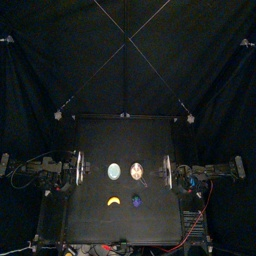

""

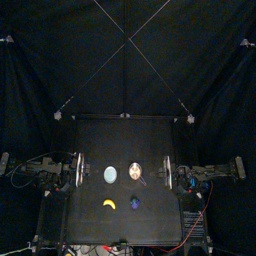

""

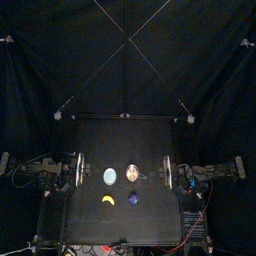

""

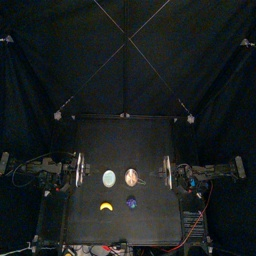

""

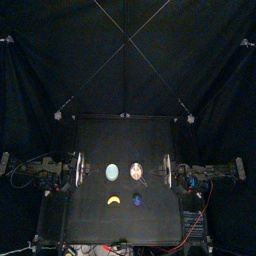

In [5]:
## write method to get the gripper coordinates for the trajectory into the same format as molmo
def get_hand_coords(left_hand, right_hand, has_left, has_right):
    left_coords, right_coords = [], []
    for lh, rh, has_left, has_right in zip(left_hand, right_hand, has_left, has_right):
        if has_left:
            left_coords.append(lh)
        if has_right:
            right_coords.append(rh)
    return left_coords, right_coords



## then ur gonna do the same thing as usual for the 


Text(0, 0.5, 'Frequency')

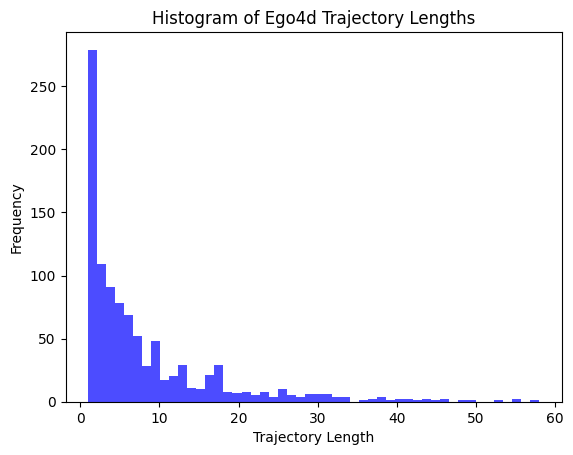

In [8]:
plt.hist(traj_lens, bins=50, alpha=0.7, color='b')
plt.title('Histogram of Ego4d Trajectory Lengths')
plt.xlabel('Trajectory Length')
plt.ylabel('Frequency')

In [50]:
ego_labels = []
ego_words = []
for i, traj in enumerate(iterator):
    lang =  traj['task']['language_instruction'][0].decode('utf-8')
    # lang = lang[2:] # remove 'C' 

    lang_words = lang.split(" ")

    ego_labels.append(lang)
    ego_words.extend(lang_words)

    if i % 5000 == 0:
        print(f"finished processing {i} trajs")


finished processing 0 trajs
finished processing 5000 trajs
finished processing 10000 trajs
finished processing 15000 trajs


2025-04-02 22:51:14.798374: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


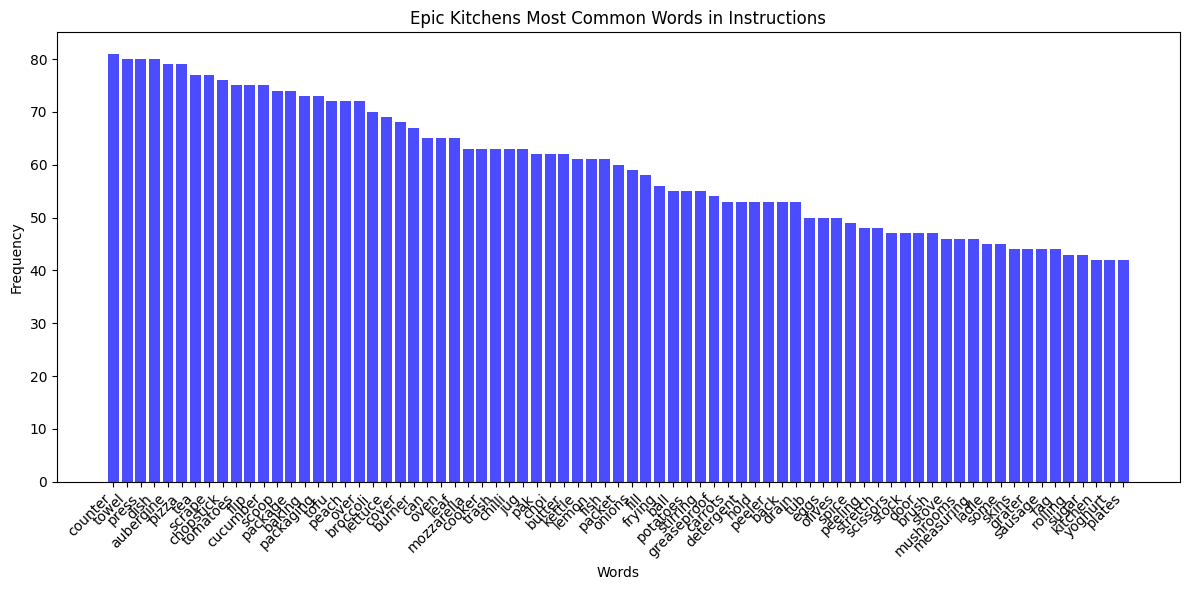

words being removed: 
put
down
up
pick
rinse


In [53]:
from collections import Counter

# Count word frequencies
word_counts = Counter(ego_words)
most_common_words = word_counts.most_common(200)  # Get top 20 words
# Get the 50 most common words from our dataset
top_50_common_words = [word for word, _ in word_counts.most_common(5)]

# Filter out these 50 most common words
filtered_word_counts = [(word, count) for word, count in word_counts.items() 
                        if word not in top_50_common_words]

# Get the 75 most common words after filtering
most_common_words = sorted(filtered_word_counts, key=lambda x: x[1], reverse=True)[125:200]



# Extract words and their counts for plotting
words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]


plt.figure(figsize=(12, 6))
plt.bar(words, counts, alpha=0.7, color='b')
plt.title('Epic Kitchens Most Common Words in Instructions')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

print("words being removed: " )
for w in top_50_common_words:
    print(w)


In [54]:
relevant_words = {
    'towel': [],
    'pizza':[],
    'tea':[],
    'chopsticks':[],
    'peach':[],
    'trash':[],
    'detergent':[],
    'can':[],
    'peeler':[],
    'scissors':[],
    'mushrooms':[],
    'sugar':[],
    'yoghurt':[],
}
    
for lang in ego_labels:
    for rw in relevant_words:
        if rw in lang:
            relevant_words[rw].append(lang)



In [69]:
# what do these buckets look like
iterator = dataset.iterator()
for i in range(5000):
    traj = next(iterator)
    lang = traj['task']['language_instruction'][0].decode('utf-8')
    if ' chopstick ' in lang:
        print(lang)
        mediapy.show_video(traj['observation']['image_primary'].squeeze(), fps=1)

use the chopstick to change the side of the egg powder mixture


This browser does not support the video tag.


slide chopstick out of dough


This browser does not support the video tag.


remove chopstick from dough


This browser does not support the video tag.


lay chopstick onto dough


This browser does not support the video tag.


put chopstick on dough


This browser does not support the video tag.


In [32]:
relevant_words['bucket']

['drops the bucket on the ground.',
 'puts the tool on bucket',
 'drops brush into the bucket of gum',
 'picks the brush in the bucket',
 'drops the paint brush in the bucket of paint. ',
 'picks the trowel from the bucket with his right hand',
 'drops the bucket of chili pepper on the ground',
 'drops the glue brush into the bucket of glue.',
 'drops the leaves into the bucket with his right hand. ',
 'moves bucket with left hand',
 'lifts the bucket by the handle with his right hand',
 'drops the molded soil in the plant bucket with his right hand.',
 'removes the bucket string from the lemon tree with her left hand',
 'drops the bucket in his left hand on the grass.',
 'drops the lemons into the bucket with her left hand ',
 'drops the sponge on the  bucket ',
 'holds the handle of the bucket with his left hand',
 'picks bucket',
 'carries out the bucket from the sink with both hands.',
 'picks up the paint brush from the paint bucket',
 'mixes cement mixture in bucket with trowel',

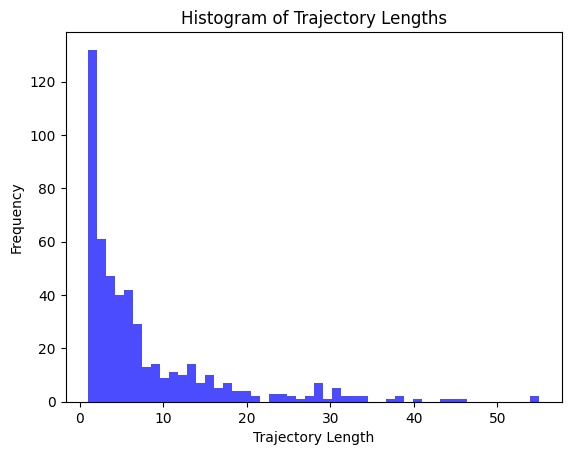

In [12]:
import matplotlib.pyplot as plt

plt.hist(traj_lens, bins=50, alpha=0.7, color='b')
plt.title('Histogram of Trajectory Lengths')
plt.xlabel('Trajectory Length')
plt.ylabel('Frequency')
plt.show()
